# 暑期科研入门培训
# 第2次课：Python基础、机器学习与深度学习基础、模型训练与代码实践

### 时间：2026年7月13日｜主讲人：陈鹏帆


# 本节课知识主线

![第2次课知识主线](assets/lesson02_knowledge_path.svg)

```text
数据 → Batch → 模型 → Logit → Loss → 梯度 → 参数更新 → 验证 → 实验记录
```


# Python基础

- 变量、对象与基本数据类型
- 列表、字典与索引
- 条件判断与循环
- 函数、参数与返回值
- 类、对象、属性与方法
- 配置与路径


# 变量、对象与基本数据类型

Python使用变量名引用对象，不需要预先声明变量类型：

```python
count = 3           # int：整数
learning_rate = 0.01 # float：浮点数
name = "model"      # str：字符串
is_training = True  # bool：布尔值
result = None        # NoneType：暂时没有值
```

| 写法 | 含义 |
|---|---|
| `=` | 赋值，把对象绑定给变量名 |
| `==`、`!=` | 判断两个值是否相等或不等 |
| `>`、`<`、`>=`、`<=` | 数值比较 |
| `and`、`or`、`not` | 组合或取反条件 |
| `type(x)` | 查看对象类型 |

Python代码块由**缩进**组织；`#`后面的内容是注释。


# Python常用容器类型

容器用于把多个对象组织在一起。常见类型包括`list`、`tuple`、`set`和`dict`；字符串`str`也具有序列特征。

| 类型 | 是否有序 | 是否可修改 | 是否允许重复 | 访问方式 |
|---|---|---|---|---|
| `list`列表 | 是 | 是 | 是 | 索引、切片 |
| `tuple`元组 | 是 | 否 | 是 | 索引、切片 |
| `set`集合 | 不依赖顺序 | 是 | 否 | 成员判断、集合运算 |
| `dict`字典 | 按插入顺序保存 | 是 | 键不能重复 | 按键访问 |
| `str`字符串 | 是 | 否 | 是 | 索引、切片 |

> `set`不能按索引读取；`dict`通过键读取，而不是通过位置读取。


# 列表与元组：相似的有序序列

## `list`：可以修改

```python
values = [1.2, -0.7, 0.5]
values[0]          # 第一个元素；索引从0开始
values[0:2]        # 切片：包含开头，不包含结尾
values.append(0.8) # 追加元素
values[1] = -0.6   # 修改元素
```

## `tuple`：创建后不能修改

```python
shape = (240, 2)
shape[0]           # 240
one_value = (3,)   # 单元素元组必须保留逗号
```

列表适合保存会变化的样本或指标；元组适合保存shape、坐标和固定结构。


# 集合与字典：按元素或键查找

## `set`：元素不重复

```python
user_ids = {101, 102, 103, 101}
101 in user_ids              # 成员判断
user_ids.add(104)            # 添加元素

train_users = {1, 2, 3}
test_users = {3, 4}
train_users & test_users     # 交集：{3}
```

集合适合去重和集合运算。空集合必须写成`set()`，因为`{}`表示空字典。

## `dict`：保存键值映射

```python
sample = {"features": [1.2, -0.7], "label": 1}
sample["label"]          # 按键读取
sample.get("user_id")    # 键不存在时返回None
sample["user_id"] = 101  # 新增或修改字段
```


# 字符串与容器选择

字符串`str`是有序但不可修改的字符序列：

```python
model_name = "LinearModel"
model_name[0]       # "L"
model_name[0:6]     # "Linear"
# model_name[0] = "M"  # 会报错
```

## 如何选择？

- 需要按位置保存并修改一组元素：`list`
- 需要按位置保存但不允许修改：`tuple`
- 需要去重、成员判断或集合运算：`set`
- 需要通过字段名或键查找数据：`dict`
- 需要保存文本、名称或路径：`str`


In [1]:
# P1. 常用容器类型与访问方式
values = [1.2, -0.7, 0.5]                   # list
shape = (240, 2)                            # tuple
user_ids = {101, 102, 103, 101}             # set
sample = {"features": [1.2, -0.7], "label": 1}  # dict
model_name = "LinearModel"                  # str

print("list索引：", values[0])
print("tuple形状：", shape)
print("set自动去重：", user_ids)
print("dict按键读取：", sample["features"])
print("str切片：", model_name[0:6])

# 多条样本通常组织为“由字典组成的列表”
samples = [
    {"features": [1.2, -0.7], "label": 1},
    {"features": [-0.8, -1.1], "label": 0},
]


第一条样本： {'features': [1.2, -0.7], 'label': 1}
输入特征： [1.2, -0.7]
标签： 1


# 条件判断与循环

- `if / elif / else`：根据条件选择执行路径；
- `for`：依次访问列表、字典或其他可迭代对象；
- `range(n)`：产生从0到`n-1`的整数；
- `enumerate(sequence)`：同时获得位置和元素。

```python
for index, sample in enumerate(samples):
    if sample["label"] == 1:
        category = "正类"
    else:
        category = "负类"
```

冒号后的代码必须正确缩进，同一代码块通常保持相同缩进层级。


In [ ]:
# P2. 条件判断与循环
# 为了让本单元格可以单独运行，这里再次定义samples
samples = [
    {"features": [1.2, -0.7], "label": 1},
    {"features": [-0.8, -1.1], "label": 0},
]

for index, item in enumerate(samples):
    if item["label"] == 1:
        category = "正类"
    else:
        category = "负类"
    print(index, item["features"], category)


# 函数：封装可复用的计算

函数把一段逻辑命名，明确它接收什么输入、返回什么结果。

```python
def function_name(parameter):
    result = parameter
    return result
```

- `def`定义函数，圆括号中是参数；
- `return`把结果返回给调用位置；
- 参数可以按位置传入，也可以使用`name=value`的关键字形式；
- 函数内部创建的普通变量通常只在函数内部使用。

阅读函数时先看**参数、返回值和调用位置**，再看内部细节。


In [3]:
# P3. 函数：明确输入和返回值
def describe_shape(num_samples, num_features):
    return f"features.shape = [{num_samples}, {num_features}]"

shape_message = describe_shape(num_samples=240, num_features=2)
print(shape_message)


features.shape = [240, 2]


# 类与对象：组织状态和行为

类可以把相关的数据和操作组织在一起，模型、数据集和优化器通常都以对象形式出现。

- `class`定义类；
- `__init__`在创建对象时初始化状态；
- `self`表示当前对象；
- `self.weight`是对象保存的属性；
- 类中定义的函数称为方法；
- `LinearRule(...)`创建一个具体对象，也称实例。

```text
类：对象应具有什么属性和方法
对象：按照这个定义创建出的具体实例
```


In [ ]:
# P4. 类与对象：把参数和计算放在一起
class LinearRule:
    def __init__(self, weight, bias):
        self.weight = weight
        self.bias = bias

    def predict(self, x):
        # 将权重与输入特征逐一配对，计算加权和，再加上偏置，得到模型的预测分数
        return sum(w * value for w, value in zip(self.weight, x)) + self.bias

rule = LinearRule([0.4, -0.2], 0.1)
print("一个logit：", rule.predict([1.2, -0.7]))


一个logit： 0.72


# 为什么需要Tensor？

![为什么引入Tensor](assets/tensor_why.svg)

> Tensor不是“另一种列表”，而是神经网络中统一表示和计算多维数值数据的基础对象。


# Tensor解决四类问题

| 能力 | 含义 |
|---|---|
| 统一表示 | 样本、Batch、模型参数和输出都使用Tensor |
| 批量计算 | 一次处理多个样本，而不是逐条手工计算 |
| 自动求导 | 从Loss出发计算参数应如何变化 |
| 设备迁移 | 同一数据流可以迁移到CPU或GPU |


# Tensor基础概念

Tensor是由数值组成的多维数组，也是PyTorch中表示数据、模型参数和计算结果的基本对象。

| 形式 | 示例 | `ndim` | `shape` |
|---|---|---:|---|
| 标量 | `3.0` | 0 | `[]` |
| 向量 | `[1.2, -0.7]` | 1 | `[2]` |
| 矩阵 | 两条二维特征 | 2 | `[2, 2]` |
| 三维Tensor | 多个矩阵组成的Batch | 3 | `[B, L, D]` |

- **维度/轴（dimension/axis）**：观察数据结构的方向；
- **`ndim`**：Tensor一共有多少个维度；
- **`shape`**：每个维度分别包含多少个元素；
- **元素数量**：`tensor.numel()`返回全部元素的个数。


# Tensor的核心属性

| 属性 | 回答的问题 | 常见示例 |
|---|---|---|
| `shape` | 数据结构是什么？ | `[batch_size, num_features]` |
| `ndim` | 有多少个维度？ | 矩阵的`ndim = 2` |
| `dtype` | 元素使用什么数据类型？ | `float32`、`long` |
| `device` | 数据位于哪个计算设备？ | `cpu`、`cuda` |
| `requires_grad` | 是否记录梯度？ | 模型参数通常为`True` |

常见类型选择：

- 连续特征、模型权重和Loss通常使用`torch.float32`；
- 分类标签是否使用浮点数或整数取决于Loss；
- Embedding索引和类别编号通常使用`torch.long`；
- 参与同一次运算的Tensor通常需要位于相同device。


In [ ]:
# T1.1 创建标量和向量
import torch
scalar = torch.tensor(3.0)                              # 0维Tensor：单个数值
vector = torch.tensor([1.2, -0.7], dtype=torch.float32) # 1维Tensor：一组数值
scalar, vector


In [ ]:
# T1.2 创建矩阵
matrix = torch.tensor([[1.2, -0.7], [0.3, 0.8]], dtype=torch.float32) # 2行2列
matrix


In [ ]:
# T1.3 创建全0和全1 Tensor
zeros = torch.zeros(2, 3) # shape为[2, 3]
ones = torch.ones(2, 3)
zeros, ones


In [ ]:
# T1.4 创建等间隔序列
sequence = torch.arange(0, 6, 2) # 从0开始，每次增加2，不包含6
sequence


In [ ]:
# T1.5 创建随机Tensor
torch.manual_seed(42)            # 固定随机种子，保证结果可复现
random_values = torch.rand(2, 2) # 生成[0, 1)之间的随机数
random_values


In [ ]:
# T1.6 检查形状、维数和元素数量
matrix.shape, matrix.ndim, matrix.numel()


In [ ]:
# T1.7 区分浮点型和整数型
scores = torch.tensor([0.8, 0.3], dtype=torch.float32) # 连续数值
user_ids = torch.tensor([0, 2, 1], dtype=torch.long)   # ID或类别索引
scores.dtype, user_ids.dtype


In [ ]:
# T1.8 查看和切换Tensor所在设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 优先使用GPU，否则使用CPU
matrix_on_device = matrix.to(device)  # 使用to(device)将Tensor移动到指定设备
matrix.device, device, matrix_on_device.device


In [ ]:
# T1.9 标记需要计算梯度的参数
parameters = torch.tensor([0.2, -0.1], requires_grad=True) # 训练时跟踪梯度
parameters.requires_grad


In [ ]:
# T2.1 准备一个二维Tensor
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]) # shape为[2, 3]
x


In [ ]:
# T2.2 使用索引读取元素
first_row = x[0]   # 读取第1行
last_value = x[1, 2] # 读取第2行、第3列
first_row, last_value


In [ ]:
# T2.3 使用切片读取局部数据
second_column = x[:, 1] # 所有行的第2列
first_two_columns = x[:, 0:2] # 结束位置2不包含在内
second_column, first_two_columns


In [ ]:
# T2.4 展平Tensor
flattened = x.reshape(-1) # [2, 3] → [6]，-1表示自动推断
flattened, flattened.shape


In [ ]:
# T2.5 重新组织形状
restored = flattened.reshape(3, 2) # 元素总数必须保持不变
restored, restored.shape


In [ ]:
# T2.6 交换两个维度
transposed = x.transpose(0, 1) # [2, 3] → [3, 2]
transposed, transposed.shape


In [ ]:
# T2.7 增加和删除长度为1的维度
single = torch.tensor([1.0, 2.0])  # 本单元格内定义，便于独立运行
batched = single.unsqueeze(0)      # [2] → [1, 2]，增加batch维
back = batched.squeeze(0)          # [1, 2] → [2]，删除长度为1的维度
batched.shape, back.shape


In [ ]:
# T3.1 准备两个形状相同的Tensor
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[0.5, 1.0], [1.5, 2.0]])
x, y


In [ ]:
# T3.2 逐元素加法
added = x + y # 对应位置的元素相加
added


In [ ]:
# T3.3 逐元素乘法
multiplied = x * y # 对应位置的元素相乘
multiplied


In [ ]:
# T3.4 矩阵乘法
product = x @ y # 按“行乘列”的规则计算
product


In [ ]:
# T3.5 广播
bias = torch.tensor([0.1, -0.1]) # shape为[2]
x + bias # bias自动加到x的每一行


In [ ]:
# T3.6 聚合：均值与求和
overall_mean = x.mean()    # 对全部元素求均值
column_sum = x.sum(dim=0) # 沿行方向聚合，得到每列之和
overall_mean, column_sum


In [ ]:
# T3.7 聚合：最大值
row_max = x.max(dim=1) # 分别寻找每一行的最大值
row_max.values, row_max.indices


In [ ]:
# T3.8 cat：沿已有维度连接
concatenated = torch.cat([x, y], dim=0) # 行数增加，维数不变
concatenated, concatenated.shape


In [ ]:
# T3.9 stack：创建新维度
stacked = torch.stack([x, y], dim=0) # 新增一个用于区分x和y的维度
stacked, stacked.shape


In [ ]:
# T3.10 转换数据类型
x_float64 = x.to(torch.float64) # float32 → float64
x.dtype, x_float64.dtype


# Shape描述的是数据结构

![Tensor形状变化](assets/tensor_shapes.svg)

常见形状：

```text
单个二维样本                 [2]
一个Batch的二维特征          [B, 2]
模型对每个样本输出一个logit  [B, 1]
Embedding索引                [B]
Embedding输出                [B, embedding_dim]
```


# Part 2｜机器学习/深度学习基础概念


# 先确定模型承担什么任务

![机器学习任务地图](assets/learning_task_map.svg)

研究问题决定任务，任务决定模型输出、Loss和评价指标。


# 推荐系统可能包含多种学习任务

| 任务 | 输出 | 推荐系统例子 |
|---|---|---|
| 回归 | 连续数值 | 预测用户评分 |
| 分类 | 类别或概率 | 预测是否点击 |
| 排序 | 候选优先顺序 | 对候选物品排序 |
| 序列预测 | 下一步事件 | 预测下一个交互物品 |
| 生成 | 新的内容序列 | 推荐理由或对话式推荐 |

下面的二维实验采用**二分类**任务。


# 训练闭环中的核心对象

![一次最小实验完整数据流](assets/experiment_pipeline.svg)

| 对象 | 问题 |
|---|---|
| 样本、特征、标签 | 模型看到了什么？要预测什么？ |
| 参数 | 模型从数据中学习什么？ |
| 前向传播 | 输入如何变成Logit？ |
| Loss | 当前预测错得多严重？ |
| 梯度 | 参数应朝哪个方向变化？ |
| Optimizer | 如何真正更新参数？ |
| 评价指标 | 模型表现如何被解释？ |


# 参数、超参数与激活函数

## 参数 vs. 超参数

- **参数**：训练中从数据学习，例如线性权重、偏置和Embedding向量
- **超参数**：实验者设置，例如学习率、Batch Size、Epoch和Embedding维度

## 为什么神经网络需要激活函数？

```text
线性层 → 激活函数 → 线性层
```

只有连续的线性变换时，整体仍然是线性的；ReLU等激活函数让模型能表达非线性关系。Sigmoid在二分类中把Logit映射为概率。


# 数据划分、推理与数据泄漏

![训练集、验证集和测试集职责](assets/data_split.svg)

| 阶段 | 是否更新参数 | 主要作用 |
|---|---:|---|
| 训练 | 是 | 学习模型参数 |
| 验证 | 否 | 调整方案、选择模型 |
| 测试 | 否 | 最终一次独立评价 |
| 推理 | 否 | 使用训练好的模型产生结果 |

**数据泄漏**：测试信息参与训练或调参，会让结果看起来很好，但不能代表未知数据表现。


# Loss、评价指标与泛化

- **Loss**：训练时提供优化方向，例如二分类交叉熵
- **评价指标**：从任务角度描述结果，例如Accuracy、Precision、Recall、AUC
- **泛化能力**：模型面对未见数据时是否仍然有效

![训练与验证曲线](assets/overfitting_curve.png)

```text
训练和验证都差 → 可能欠拟合
训练持续变好、验证开始变差 → 可能过拟合
```



# 重要模型

![重要模型演进地图](assets/model_evolution_map.svg)

每个模型只回答四个问题：

1. 输入是什么？
2. 核心处理机制是什么？
3. 输出是什么？
4. 与推荐系统有什么联系？


# 固定特征模型：线性、树与MLP

![线性模型、决策树与MLP](assets/model_linear_tree_mlp.svg)


# 线性、树与MLP的理论重点

| 模型 | 核心机制 | 推荐系统中的可能用途 |
|---|---|---|
| 线性/逻辑回归 | 特征加权求和，必要时映射为概率 | 点击预测、线性打分基础 |
| 决策树 | 按条件递归划分样本 | 处理用户、物品和上下文结构化特征 |
| MLP | 多层连接和激活函数学习非线性组合 | 融合用户、物品和上下文表示 |

模型选择取决于任务、数据和实验目标。


# 序列处理：CNN与RNN/LSTM

![CNN与RNN/LSTM序列处理](assets/model_cnn_rnn.svg)


# CNN与RNN/LSTM的理论重点

- **CNN**：使用局部窗口和共享参数发现邻近模式
- **RNN**：隐藏状态沿顺序传递，当前状态包含部分历史信息
- **LSTM**：通过门控机制改善长期信息保存

推荐系统中的对应问题：

```text
用户依次浏览/点击了什么？
最近几个行为是否形成局部兴趣模式？
兴趣如何随时间发生变化？
```


# Transformer：用Attention建模序列关系

![Transformer理论示意图](assets/model_transformer.svg)


# Transformer：Attention与序列建模

- 输入通常先变成Embedding，并加入位置信息
- Self-Attention让每个位置直接寻找相关的其他位置
- 不同历史行为对当前预测可以具有不同权重
- 相比逐步传递隐藏状态，更适合并行处理和长距离关系建模

推荐系统中的常见用途：

```text
用户行为序列 → Transformer → 序列表示 → 下一物品预测
```


# 模型地图小结

- 线性模型通过特征加权产生分数；
- MLP通过多层非线性变换增强表达能力；
- CNN关注局部模式；
- RNN/LSTM沿序列传递状态；
- Transformer使用Attention建模位置之间的关系；
- 序列模型可以用于理解用户行为随时间的变化。


# Part 3｜二维二分类完整实验

使用可视化二维数据走通一次完整训练闭环：

```text
生成数据 → 划分数据 → DataLoader → Linear → Logit → BCE Loss → Backward → Optimizer → Validation → Test → 实验记录
```


In [1]:
# 0. 导入依赖并固定随机性
from copy import deepcopy
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("PyTorch版本：", torch.__version__)
print("随机种子：", SEED)


PyTorch版本： 2.12.1+cpu
随机种子： 42


In [22]:
# 1. 生成二维二分类数据

# 设置每个类别的样本数量。
# 本例包含两个类别，因此最终会生成 120 × 2 = 240 个样本。
num_per_class = 120

# 创建一个独立的随机数生成器，并使用 SEED 设置随机种子。
# 固定随机种子可以保证每次运行代码时生成相同的随机数据，便于实验复现。
generator = torch.Generator().manual_seed(SEED)

# 生成类别 0 的样本：
# 1. torch.randn(num_per_class, 2) 生成 120 个二维标准正态分布样本；
# 2. 乘以 0.70，控制样本的离散程度；
# 3. 加上 [-1.0, -1.0]，将样本中心移动到坐标 (-1, -1) 附近。
class_0 = (
    torch.randn(num_per_class, 2, generator=generator) * 0.70
    + torch.tensor([-1.0, -1.0])
)

# 生成类别 1 的样本。
# 生成方式与类别 0 相同，但样本中心被移动到坐标 (1, 1) 附近。
class_1 = (
    torch.randn(num_per_class, 2, generator=generator) * 0.70
    + torch.tensor([1.0, 1.0])
)

# 沿第 0 维（样本维度）拼接两个类别的特征。
# 拼接后的 features 形状为 [240, 2]：
# - 240 表示样本总数；
# - 2 表示每个样本有两个特征。
# float() 将数据类型统一转换为 torch.float32。
features = torch.cat([class_0, class_1], dim=0).float()

# 为两个类别创建标签：
# - 类别 0 的 120 个样本对应标签 0；
# - 类别 1 的 120 个样本对应标签 1。
# 拼接后的 labels 形状为 [240]。
# 二分类模型通常使用浮点型标签计算二元交叉熵损失。
labels = torch.cat(
    [
        torch.zeros(num_per_class),
        torch.ones(num_per_class),
    ],
    dim=0,
).float()

# 输出特征张量的形状和数据类型，检查数据是否符合预期。
print("features:", features.shape, features.dtype)

# 输出标签张量的形状和数据类型。
print("labels:  ", labels.shape, labels.dtype)


features: torch.Size([240, 2]) torch.float32
labels:   torch.Size([240]) torch.float32


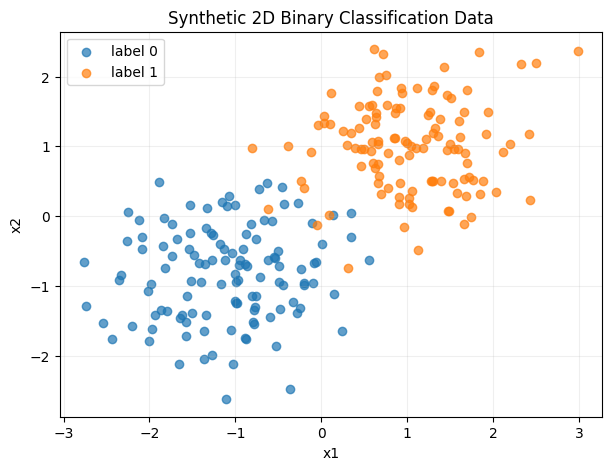

In [23]:
# 2. 画图：先观察数据，再写模型
plt.figure(figsize=(7, 5))
plt.scatter(features[labels == 0, 0], features[labels == 0, 1], alpha=0.7, label="label 0")
plt.scatter(features[labels == 1, 0], features[labels == 1, 1], alpha=0.7, label="label 1")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Synthetic 2D Binary Classification Data")
plt.legend(); plt.grid(alpha=0.2); plt.show()


In [10]:
# 3. 固定随机划分train / validation / test
indices = torch.randperm(len(features), generator=torch.Generator().manual_seed(SEED))
train_idx, valid_idx, test_idx = indices[:160], indices[160:200], indices[200:]

train_x, train_y = features[train_idx], labels[train_idx]
valid_x, valid_y = features[valid_idx], labels[valid_idx]
test_x, test_y = features[test_idx], labels[test_idx]
print("train / valid / test：", len(train_x), len(valid_x), len(test_x))


train / valid / test： 160 40 40


# DataLoader：把Dataset组织成可迭代的Batch

训练时通常不会手动逐条读取样本。PyTorch用Dataset描述“如何取得一条样本”，再由DataLoader按照设定的规则持续产生Batch。

| 组件 | 主要作用 | 本实验中的对象 |
|---|---|---|
| Dataset | 保存样本，并支持按索引读取一条数据 | `TensorDataset(train_x, train_y)` |
| DataLoader | 从Dataset取样、组成Batch并提供迭代器 | `DataLoader(train_set, batch_size=16)` |

DataLoader在一次迭代中主要完成：

1. 根据索引从Dataset取得若干样本；
2. 将这些样本自动堆叠成一个Batch；
3. 依次返回`batch_features`和`batch_labels`；
4. 所有Batch遍历一遍，就完成了一个Epoch。

常用参数：

- `batch_size`：每个Batch包含多少条样本；
- `shuffle=True`：每个Epoch开始前重新打乱训练样本顺序；
- `drop_last=True`：丢弃最后一个不足`batch_size`的Batch；
- `num_workers`：使用多少个子进程并行读取数据，入门实验可保持默认值`0`。

注意：DataLoader负责组织和提供数据，**不会计算Logit、Loss，也不会更新模型参数**。验证集和测试集通常不需要打乱。


In [11]:
# 4. Dataset → DataLoader → batch
BATCH_SIZE = 16
train_set = TensorDataset(train_x, train_y)
valid_set = TensorDataset(valid_x, valid_y)
test_set = TensorDataset(test_x, test_y)

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
valid_loader = DataLoader(valid_set, BATCH_SIZE)
test_loader = DataLoader(test_set, BATCH_SIZE)
print("训练集batch数量：", len(train_loader))


训练集batch数量： 10


In [12]:
# 5. 查看一个batch
preview_loader = DataLoader(train_set, BATCH_SIZE, shuffle=False)  # 仅用于课堂预览，不影响训练顺序
batch_features, batch_labels = next(iter(preview_loader))
print("batch_features.shape：", batch_features.shape)
print("batch_labels.shape：  ", batch_labels.shape)
print("features dtype：", batch_features.dtype)
print("labels dtype：  ", batch_labels.dtype)
print("第一条样本：", batch_features[0], "label=", batch_labels[0])


batch_features.shape： torch.Size([16, 2])
batch_labels.shape：   torch.Size([16])
features dtype： torch.float32
labels dtype：   torch.float32
第一条样本： tensor([-0.8704, -0.2519]) label= tensor(0.)


In [25]:
# 6. 定义最小模型：[B, 2] → [B, 1] → [B]
model = nn.Linear(in_features=2, out_features=1)
with torch.no_grad():
    model.weight.copy_(torch.tensor([[0.4, -0.2]]))
    model.bias.fill_(0.1)
output=model(batch_features)
print(output.shape)
logits = model(batch_features).squeeze(dim=1)
print(model)
print("logits.shape：", logits.shape)
print("labels.shape：", batch_labels.shape)


torch.Size([16, 1])
Linear(in_features=2, out_features=1, bias=True)
logits.shape： torch.Size([16])
labels.shape： torch.Size([16])


In [14]:
# 7. 一个batch的loss必须是标量
loss_fn = nn.BCEWithLogitsLoss()
logits = model(batch_features).squeeze(dim=1)
loss = loss_fn(logits, batch_labels)
print("logits.shape：", logits.shape)
print("labels.shape：", batch_labels.shape)
print("loss.shape：", loss.shape)
print("loss：", loss.item())


logits.shape： torch.Size([16])
labels.shape： torch.Size([16])
loss.shape： torch.Size([])
loss： 0.5599406957626343


# 一次参数更新发生了什么？

![训练循环](assets/training_cycle.svg)

```python
optimizer.zero_grad()  # 清除上一轮梯度
loss.backward()        # 根据Loss计算梯度
optimizer.step()       # 根据梯度更新参数
```

这三行不是“固定仪式”，而是在完成：清理旧信息 → 计算改变方向 → 真正改变参数。


In [15]:
# 8. 执行一次更新，确认参数真的改变
update_demo = deepcopy(model)
optimizer = torch.optim.SGD(update_demo.parameters(), lr=0.2)
before = update_demo.weight.detach().clone()

optimizer.zero_grad()
demo_loss = loss_fn(update_demo(batch_features).squeeze(1), batch_labels)
demo_loss.backward()
optimizer.step()

after = update_demo.weight.detach().clone()
print("更新前：", before)
print("更新后：", after)
print("参数变化量：", (after-before).abs().sum().item())


更新前： tensor([[ 0.4000, -0.2000]])
更新后： tensor([[ 0.5032, -0.1115]])
参数变化量： 0.1916758120059967


In [16]:
# 9. 验证函数：只评价，不更新参数
def evaluate(model, data_loader):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    with torch.no_grad():
        for x, y in data_loader:
            logits = model(x).squeeze(1)
            total_loss += loss_fn(logits, y).item() * len(y)
            predictions = (torch.sigmoid(logits) >= 0.5).float()
            total_correct += (predictions == y).sum().item()
            total_count += len(y)
    return total_loss / total_count, total_correct / total_count


In [17]:
# 10. 一个epoch：训练集参与参数更新
def train_one_epoch(model, data_loader, optimizer):
    model.train()
    total_loss, total_count = 0.0, 0
    for x, y in data_loader:
        optimizer.zero_grad()
        logits = model(x).squeeze(1)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        total_count += len(y)
    return total_loss / total_count


In [18]:
# 11. 完整训练：验证集选择最佳模型
model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)
history, best_state, best_valid_loss = [], None, float("inf")

for epoch in range(1, 31):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    valid_loss, valid_acc = evaluate(model, valid_loader)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "valid_loss": valid_loss, "valid_acc": valid_acc})
    if valid_loss < best_valid_loss:
        best_valid_loss, best_state = valid_loss, deepcopy(model.state_dict())
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | train {train_loss:.4f} | "
              f"valid {valid_loss:.4f} | acc {valid_acc:.3f}")

history = pd.DataFrame(history)


Epoch 01 | train 0.2987 | valid 0.2513 | acc 0.950
Epoch 05 | train 0.1042 | valid 0.1410 | acc 0.925
Epoch 10 | train 0.0726 | valid 0.1152 | acc 0.925
Epoch 15 | train 0.0608 | valid 0.1054 | acc 0.925
Epoch 20 | train 0.0542 | valid 0.1004 | acc 0.925
Epoch 25 | train 0.0501 | valid 0.0974 | acc 0.925
Epoch 30 | train 0.0472 | valid 0.0956 | acc 0.925


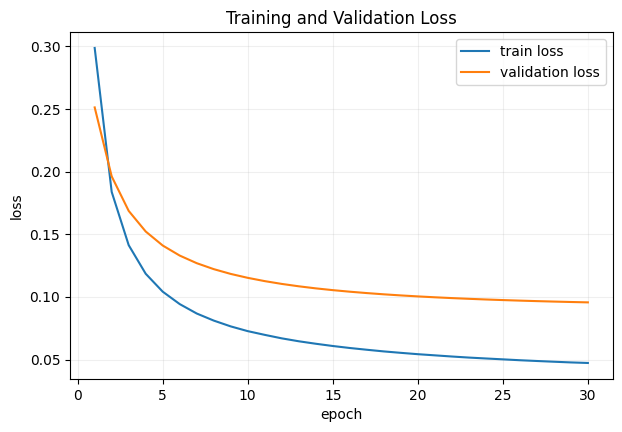

,epoch,train_loss,valid_loss,valid_acc
25,26,0.049415,0.097008,0.925
26,27,0.048807,0.096612,0.925
27,28,0.048225,0.096248,0.925
28,29,0.047669,0.095913,0.925
29,30,0.047228,0.095610,0.925


In [19]:
# 12. 画出训练与验证loss
plt.figure(figsize=(7, 4.5))
plt.plot(history["epoch"], history["train_loss"], label="train loss")
plt.plot(history["epoch"], history["valid_loss"], label="validation loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.grid(alpha=0.2); plt.show()

history.tail()


In [20]:
# 13. 恢复最佳验证模型，最后检查test集
best_epoch = int(history.loc[history["valid_loss"].idxmin(), "epoch"])
model.load_state_dict(best_state)
test_loss, test_acc = evaluate(model, test_loader)

print("最佳验证epoch：", best_epoch)
print("最佳验证loss：", round(best_valid_loss, 4))
print("最终test loss：", round(test_loss, 4))
print("最终test accuracy：", round(test_acc, 3))




最佳验证epoch： 30
最佳验证loss： 0.0956
最终test loss： 0.1547
最终test accuracy： 0.975


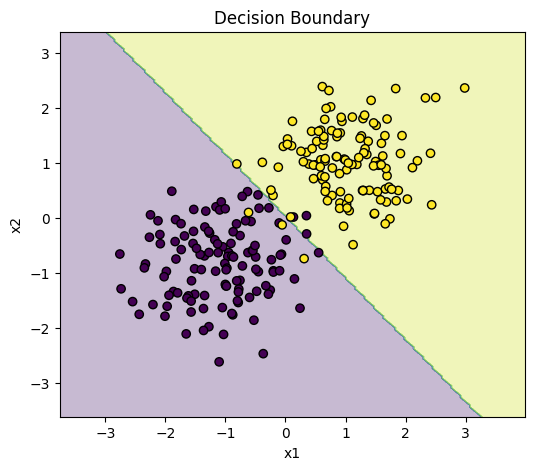

In [24]:
# 绘制二维分类边界

import numpy as np
import matplotlib.pyplot as plt


model.eval()

# 取全部数据用于可视化
all_x = features
all_y = labels


# 创建二维网格
x_min = all_x[:, 0].min() - 1
x_max = all_x[:, 0].max() + 1

y_min = all_x[:, 1].min() - 1
y_max = all_x[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)


# 将网格点转换为模型输入
grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32
)


# 预测每个网格点
with torch.no_grad():
    logits = model(grid).squeeze(1)
    preds = (logits > 0).float()


# 恢复二维形状
preds = preds.reshape(xx.shape)


# 绘制分类区域
plt.figure(figsize=(6,5))

plt.contourf(
    xx,
    yy,
    preds,
    alpha=0.3
)


# 绘制真实样本点
plt.scatter(
    all_x[:,0],
    all_x[:,1],
    c=all_y,
    edgecolors="k"
)


plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary")

plt.show()

In [21]:
# 14. 用shape表复述完整数据流
shape_table = pd.DataFrame([
    ["全部输入", "features", tuple(features.shape)],
    ["一个batch", "batch_features", tuple(batch_features.shape)],
    ["模型输出", "logits", tuple(model(batch_features).squeeze(1).shape)],
    ["真实标签", "batch_labels", tuple(batch_labels.shape)],
    ["批次损失", "loss", tuple(loss.shape)],
], columns=["阶段", "变量", "shape"])
shape_table


,阶段,变量,shape
0,全部输入,features,"(240, 2)"
1,一个batch,batch_features,"(16, 2)"
2,模型输出,logits,"(16,)"
3,真实标签,batch_labels,"(16,)"
4,批次损失,loss,()


# 二维实验关键组件

```text
TensorDataset：把features和labels组织成可索引样本
DataLoader：把样本组成Batch
nn.Linear：把[B,2]变成[B,1]
squeeze：让logits和labels形状对齐
BCEWithLogitsLoss：比较Logit和0/1标签
backward：计算参数梯度
optimizer.step：更新参数
evaluate：只评价，不更新参数
```


# Part 4｜Embedding与用户—物品点积

二维分类使用连续特征：

```text
[x₁, x₂] → Linear → Logit
```

推荐数据经常首先给出离散ID：

```text
user_id + item_id → ? → 匹配分数
```

问题：ID只是类别标识，为什么不能直接把编号大小当作连续特征？


# Embedding：可训练的向量查找表

![Embedding查表示意图](assets/embedding_lookup.svg)

- 原始ID先映射为连续索引
- 索引Tensor通常使用`torch.long`
- 每个索引查到一行可训练向量
- 输出shape为`[batch_size, embedding_dim]`
- Embedding向量和线性权重一样，可以通过Loss与反向传播更新


In [24]:
# 15. 读取现有用户—物品数据
candidate_paths = [Path("data/interactions.csv"),
                   Path("courses/lesson02/data/interactions.csv")]
interaction_path = next(p for p in candidate_paths if p.exists())
interactions = pd.read_csv(interaction_path)

print("数据文件：", interaction_path)
print("数据shape：", interactions.shape)
interactions.head()


数据文件：

 data\interactions.csv
数据shape： (120, 3)


,user_id,item_id,label
0,U01,I14,1
1,U01,I17,0
2,U01,I04,0
3,U01,I16,0
4,U01,I20,0


In [25]:
# 16. 原始ID映射为连续编号
user_to_index = {u: i for i, u in enumerate(sorted(interactions.user_id.unique()))}
item_to_index = {v: i for i, v in enumerate(sorted(interactions.item_id.unique()))}
interactions["user_index"] = interactions.user_id.map(user_to_index)
interactions["item_index"] = interactions.item_id.map(item_to_index)

print("用户数量：", len(user_to_index))
print("物品数量：", len(item_to_index))
interactions.head()


用户数量： 12
物品数量： 20


,user_id,item_id,label,user_index,item_index
0,U01,I14,1,0,13
1,U01,I17,0,0,16
2,U01,I04,0,0,3
3,U01,I16,0,0,15
4,U01,I20,0,0,19


In [26]:
# 17. ID查表得到向量，再通过点积得到logit
embedding_dim = 4
user_embedding = nn.Embedding(len(user_to_index), embedding_dim)
item_embedding = nn.Embedding(len(item_to_index), embedding_dim)

users = torch.tensor(interactions.user_index.iloc[:5].to_numpy(), dtype=torch.long)
items = torch.tensor(interactions.item_index.iloc[:5].to_numpy(), dtype=torch.long)
user_vectors, item_vectors = user_embedding(users), item_embedding(items)
scores = (user_vectors * item_vectors).sum(dim=1)
print("users：", users.shape, "→ user_vectors：", user_vectors.shape)
print("items：", items.shape, "→ item_vectors：", item_vectors.shape)
print("scores：", scores.shape)


users： torch.Size([5]) → user_vectors： torch.Size([5, 4])
items： torch.Size([5]) → item_vectors： torch.Size([5, 4])
scores： torch.Size([5])


# 用户—物品点积在计算什么？

$$
s(u,i)=\mathbf e_u^{\top}\mathbf e_i
$$

```text
user_id → user_index → user_embedding ┐
                                      ├→ 点积 → 匹配Logit
item_id → item_index → item_embedding ┘
```

点积是一种最小匹配方式：两个向量在当前表示空间中越匹配，分数通常越高。这里不把它解释成完整推荐系统。


# 输入表示变了，训练骨架没有变

![通用二分类与用户—物品模型对照](assets/model_comparison.svg)

| 保持不变 | 发生变化 |
|---|---|
| Batch训练 | 连续特征变成用户/物品ID |
| Logit与0/1标签 | `Linear`变成`Embedding + 点积` |
| BCE Loss | 每个ID对应一行可训练向量 |
| Backward与Optimizer | 模型参数中加入Embedding表 |



# Embedding关键问题

- 为什么用户ID不能直接按数值大小参与计算？
- 为什么Embedding索引使用`long`？
- `[B]`的索引经过Embedding后为什么变成`[B, D]`？
- 用户向量与物品向量如何产生一个分数？
- 哪些训练步骤与二维分类保持不变？


# Part 5｜课后作业


- 完整运行二维二分类代码（或者其他深度学习模型），并保留以下关键结果：
  - 二维数据分布；
  - 训练过程中的Loss；
  - 验证集结果；
  - 分类边界或最终预测结果。

- 找到并标注以下关键代码：
  - 数据生成与数据集划分；
  - Tensor与Batch构造；
  - 模型定义；
  - Loss定义；
  - Optimizer定义；
  - 训练循环；
  - 验证与预测；
  - 标出至少三个关键位置的数据shape。

- 结合本次实验，用自己的话解释以下概念：
  - Tensor；
  - Batch；
  - Epoch；
  - Logit；
  - Loss。


- 按照第一次课的科研记录要求，补充一份实验记录：
  - 我运行了什么；
  - 我得到了什么结果；
  - 我遇到了什么问题；
  - 我尝试了什么；
  - 我如何判断代码已经跑通；
  - 是否使用了AI/Agent，以及自己核对了哪些内容。
